# Lab 29 — LR accuracy, threshold and missingness ablation

So sánh baseline LR trên 626 ca thật của Cleveland, Switzerland và VA.
Hungarian không được tải hoặc đánh giá. Không few-shot, không lấy support khỏi test.

## Protocol đã khóa
- Outer LOCO: train 2 hospitals, đánh giá toàn bộ hospital thứ 3.
- Inner LOCO trên 2 source hospitals: mỗi lượt train 1, validation 1.
- Nhánh LR mới: cùng grid C, chọn theo mean hospital Accuracy tại threshold 0.5.
- Sau khi chọn C/resampling bằng inner CV, dùng inner OOF để chọn threshold.
- Ba operating points: 0.5; max macro Accuracy; max macro Accuracy với Recall >= 0.80 **ở cả hai inner hospitals**.
- Ràng buộc Recall ở inner CV không bảo đảm Recall ở outer hospital.
- Báo cáo mọi nhánh; không tự động chọn winner từ outer labels hoặc xuất model production.

Legacy Lab 28 được tái hiện ở nhánh riêng (Optuna tối ưu AUC, SMOTENC + positive weight).
Nhánh mới sửa thứ tự preprocessing: fit imputation/scaling trên real train; missing indicators
được lấy trước imputation và coi là categorical khi SMOTENC. Đây không phải ablation
một yếu tố so với legacy. Ablation giữa các nhánh mới dùng cùng pipeline.

Không so trực tiếp số tuyệt đối với 0.6273: Lab 28 đánh giá query sau khi bỏ support,
Lab 29 đánh giá toàn bộ outer hospital. Mean là macro, mỗi hospital trọng số bằng nhau.
Kết quả là nghiên cứu exploratory trên các hospitals đã được khảo sát nhiều lần.

In [1]:
!pip -q install "scikit-learn==1.6.1" "imbalanced-learn==0.13.0" "optuna==4.2.1" seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 15.1 MB/s eta 0:00:00


In [2]:
import json
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from IPython.display import display
from imblearn.over_sampling import SMOTENC
from scipy.special import expit
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 100)

FEATURES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal",
]
TARGET = "target"
SITE = "site"
NUMERICAL_FEATURES = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL_FEATURES = [
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal",
]

BASE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease"
FILES = {
    "cleveland": "processed.cleveland.data",
    "switzerland": "processed.switzerland.data",
    "va": "processed.va.data",
}
COLUMNS = FEATURES + ["num"]
DEVELOPMENT_SITES = ["cleveland", "switzerland", "va"]

MODEL_SEEDS = (42, 123, 2025)
N_TRIALS = 10
THRESHOLD = 0.50

OUTPUT_DIR = Path("/content/uci_multicenter_lr_accuracy_lab29_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_DATA_DIR_CANDIDATES = [
    Path("/content/heart-disease-diagnosis/data/raw/uci_multicenter"),
    Path("/content/data/raw/uci_multicenter"),
    Path("data/raw/uci_multicenter"),
    Path("../data/raw/uci_multicenter"),
]
LOCAL_DATA_DIR = next(
    (path for path in LOCAL_DATA_DIR_CANDIDATES if path.exists()),
    None,
)

print("Development sites:", DEVELOPMENT_SITES)
print("Model seeds:", MODEL_SEEDS)
print("External holdout loaded:", False)
from sklearn.metrics import balanced_accuracy_score
import platform, importlib.metadata, shutil
C_GRID = (0.01, 0.1, 1.0, 10.0)
RATIO_GRID = (0.5, 0.75, 1.0)
RECALL_FLOOR = 0.80
THRESHOLDS = np.r_[np.linspace(0, 1, 201), np.nextafter(1.0, 2.0)]
LOCAL_DATA_DIR_CANDIDATES += [Path('../../data/raw/uci_multicenter')]
LOCAL_DATA_DIR = next((p for p in LOCAL_DATA_DIR_CANDIDATES if p.exists()), None)

Development sites: ['cleveland', 'switzerland', 'va']
Model seeds: (42, 123, 2025)
External holdout loaded: False


In [3]:
def read_uci(site, filename):
    source = (LOCAL_DATA_DIR / filename) if LOCAL_DATA_DIR else f"{BASE_URL}/{filename}"
    frame = pd.read_csv(
        source,
        names=COLUMNS,
        na_values=["?"],
        skipinitialspace=True,
    )
    frame = frame.apply(pd.to_numeric, errors="coerce")
    assert frame["num"].notna().all()
    assert frame["num"].isin([0, 1, 2, 3, 4]).all()
    frame[TARGET] = (frame["num"] > 0).astype("int8")
    frame[SITE] = site
    return frame[FEATURES + [TARGET, SITE]]


development = pd.concat(
    [read_uci(site, filename) for site, filename in FILES.items()],
    ignore_index=True,
)

assert len(development) == 626
assert set(development[SITE]) == set(DEVELOPMENT_SITES)

site_summary = development.groupby(SITE).agg(
    rows=(TARGET, "size"),
    positives=(TARGET, "sum"),
    positive_rate=(TARGET, "mean"),
).reset_index()

missing_by_site = development.groupby(SITE)[FEATURES].apply(
    lambda frame: frame.isna().mean()
).T

print("Data source:", str(LOCAL_DATA_DIR) if LOCAL_DATA_DIR else "UCI URL fallback")
print("Development shape:", development.shape)
display(site_summary.round(4))
display(pd.crosstab(development[SITE], development[TARGET], margins=True))
display((missing_by_site * 100).round(1))

site_summary.to_csv(OUTPUT_DIR / "development_site_summary.csv", index=False)
missing_by_site.to_csv(OUTPUT_DIR / "development_missing_by_site.csv")

Data source: UCI URL fallback
Development shape: (626, 15)


,site,rows,positives,positive_rate
0,cleveland,303,139,0.4587
1,switzerland,123,115,0.9350
2,va,200,149,0.7450


target,0,1,All
site,,,
cleveland,164,139,303
switzerland,8,115,123
va,51,149,200
All,223,403,626


site,cleveland,switzerland,va
age,0.0,0.0,0.0
sex,0.0,0.0,0.0
cp,0.0,0.0,0.0
trestbps,0.0,1.6,28.0
chol,0.0,0.0,3.5
fbs,0.0,61.0,3.5
restecg,0.0,0.8,0.0
thalach,0.0,0.8,26.5
exang,0.0,0.8,26.5
oldpeak,0.0,4.9,28.0


## Legacy reference — giữ nguyên hàm fit/tune của Lab 28, không adaptation

In [4]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)


def apply_p1(frame):
    out = frame.copy()
    for column in FEATURES:
        out[column] = pd.to_numeric(out[column], errors="coerce")

    # P1: sentinel đã được đọc thành NaN; thêm rule có căn cứ cho giá trị không hợp lệ.
    for column in ["trestbps", "chol"]:
        out.loc[out[column] <= 0, column] = np.nan

    return out


def make_preprocessor(scale_numeric=True):
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer([
        ("numerical", Pipeline(numeric_steps), NUMERICAL_FEATURES),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(
                strategy="most_frequent",
                add_indicator=True,
            )),
            ("encoder", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            )),
        ]), CATEGORICAL_FEATURES),
    ])


def make_preprocessor_compat(scale_numeric=True):
    try:
        return make_preprocessor(scale_numeric)
    except TypeError:
        numeric_steps = [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ]
        if scale_numeric:
            numeric_steps.append(("scaler", StandardScaler()))
        return ColumnTransformer([
            ("numerical", Pipeline(numeric_steps), NUMERICAL_FEATURES),
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(
                    strategy="most_frequent",
                    add_indicator=True,
                )),
                ("encoder", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse=False,
                )),
            ]), CATEGORICAL_FEATURES),
        ])


def apply_smotenc(train_frame, seed):
    ready = apply_p1(train_frame).reset_index(drop=True)
    y = ready[TARGET].to_numpy(dtype="int8")

    counts = np.bincount(y, minlength=2)
    if counts.min() < 2:
        return ready

    # Impute từng cột thủ công để giữ đủ 13 cột. SimpleImputer mặc định
    # có thể loại cột toàn-missing trong một training fold, làm lệch
    # categorical_indices của SMOTENC.
    def fill_train_only(columns, strategy):
        filled_columns = []
        for column in columns:
            values = pd.to_numeric(ready[column], errors="coerce")
            if strategy == "median":
                fill_value = values.median()
            else:
                modes = values.dropna().mode()
                fill_value = modes.iloc[0] if not modes.empty else 0.0
            if pd.isna(fill_value):
                fill_value = 0.0
            filled_columns.append(
                values.fillna(float(fill_value)).to_numpy(dtype="float64")
            )
        return np.column_stack(filled_columns)

    x_numeric = fill_train_only(NUMERICAL_FEATURES, "median")
    x_categorical = fill_train_only(CATEGORICAL_FEATURES, "mode")
    x_for_smote = np.column_stack([x_numeric, x_categorical])

    categorical_indices = list(range(
        len(NUMERICAL_FEATURES),
        len(NUMERICAL_FEATURES) + len(CATEGORICAL_FEATURES),
    ))
    k_neighbors = max(1, min(5, int(counts.min()) - 1))

    sampler = SMOTENC(
        categorical_features=categorical_indices,
        k_neighbors=k_neighbors,
        random_state=seed,
    )
    x_resampled, y_resampled = sampler.fit_resample(x_for_smote, y)

    resampled = pd.DataFrame(
        x_resampled,
        columns=NUMERICAL_FEATURES + CATEGORICAL_FEATURES,
    )
    for column in CATEGORICAL_FEATURES:
        resampled[column] = np.rint(resampled[column]).astype(float)

    resampled[TARGET] = y_resampled.astype("int8")
    resampled[SITE] = "train_only_smotenc"
    return resampled[FEATURES + [TARGET, SITE]]


def frame_xy(frame):
    ready = apply_p1(frame)
    return ready[FEATURES], ready[TARGET].to_numpy(dtype="int8")

In [5]:
def suggest_lr_params(trial):
    return {
        "C": trial.suggest_float("C", 0.01, 10.0, log=True),
        "solver": trial.suggest_categorical(
            "solver",
            ["lbfgs", "liblinear"],
        ),
        "positive_weight": trial.suggest_float(
            "positive_weight",
            0.75,
            2.0,
        ),
        "max_iter": 3000,
    }


def fit_lr_smotenc(train_frame, params, seed):
    seed_everything(seed)
    sampled = apply_smotenc(train_frame, seed)
    x_train, y_train = frame_xy(sampled)

    preprocessor = make_preprocessor_compat(scale_numeric=True)
    x_train = preprocessor.fit_transform(x_train).astype("float32")

    estimator = LogisticRegression(
        C=float(params["C"]),
        solver=str(params["solver"]),
        max_iter=int(params.get("max_iter", 3000)),
        class_weight={
            0: 1.0,
            1: float(params["positive_weight"]),
        },
        random_state=seed,
    )
    estimator.fit(x_train, y_train)
    return preprocessor, estimator


def transform_features(preprocessor, frame):
    x_frame, _ = frame_xy(frame)
    return preprocessor.transform(x_frame).astype("float32")


def predict_probability(preprocessor, estimator, frame, intercept=None):
    x_frame = transform_features(preprocessor, frame)
    raw_intercept = (
        float(estimator.intercept_[0])
        if intercept is None else float(intercept)
    )
    logits = x_frame @ estimator.coef_[0] + raw_intercept
    return expit(logits)


def tune_source_model(source_frame, seed, n_trials=N_TRIALS):
    labels = source_frame[TARGET].to_numpy(dtype="int8")
    groups = source_frame[SITE].to_numpy()
    splits = list(GroupKFold(n_splits=2).split(
        source_frame,
        labels,
        groups,
    ))

    def objective(trial):
        params = suggest_lr_params(trial)
        fold_auc = []

        for fold_number, (fit_idx, valid_idx) in enumerate(splits):
            fit_frame = source_frame.iloc[fit_idx].reset_index(drop=True)
            valid_frame = source_frame.iloc[valid_idx].reset_index(drop=True)

            preprocessor, estimator = fit_lr_smotenc(
                fit_frame,
                params,
                seed + fold_number,
            )
            probability = predict_probability(
                preprocessor,
                estimator,
                valid_frame,
            )
            fold_auc.append(roc_auc_score(
                valid_frame[TARGET],
                probability,
            ))

        return float(np.mean(fold_auc))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3),
    )
    started = time.perf_counter()
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=1,
        show_progress_bar=False,
    )

    best_params = dict(study.best_trial.params)
    best_params["max_iter"] = 3000
    return study, best_params, time.perf_counter() - started

## Controlled LR branches — cùng preprocessing và grid C

In [6]:
BRANCHES = {
    'lr_plain': dict(sampling=False, balanced=False, indicators=True, drop=False),
    'lr_weighted': dict(sampling=False, balanced=True, indicators=True, drop=False),
    'lr_smotenc': dict(sampling=True, balanced=False, indicators=True, drop=False),
    'lr_smotenc_ratio': dict(sampling=True, balanced=False, indicators=True, drop=False),
    'lr_smotenc_no_indicators': dict(sampling=True, balanced=False, indicators=False, drop=False),
    'lr_smotenc_drop_ca_thal': dict(sampling=True, balanced=False, indicators=True, drop=True),
    'lr_smotenc_drop_ca_thal_no_indicators': dict(sampling=True, balanced=False, indicators=False, drop=True),
}

def fit_controlled(train, config, C, ratio, seed):
    features = [f for f in FEATURES if not (config['drop'] and f in ['ca', 'thal'])]
    numeric = [f for f in NUMERICAL_FEATURES if f in features]
    categorical = [f for f in CATEGORICAL_FEATURES if f in features]
    raw = apply_p1(train)[numeric + categorical]
    fill = {}
    for f in raw:
        values = raw[f].dropna()
        fill[f] = (values.median() if f in numeric else values.mode().iloc[0]) if len(values) else 0.0
    scaler = StandardScaler().fit(raw[numeric].fillna(fill))
    def transform(frame):
        x = apply_p1(frame)[numeric + categorical]
        pieces = [scaler.transform(x[numeric].fillna(fill)), x[categorical].fillna(fill).to_numpy()]
        if config['indicators']:
            pieces.append(x.isna().astype(float).to_numpy())
        return np.column_stack(pieces)
    x = transform(train)
    y = train[TARGET].to_numpy()
    cat_indices = list(range(len(numeric), x.shape[1]))
    if config['sampling']:
        counts = np.bincount(y, minlength=2)
        # Do not undersample when requested ratio is already reached.
        if counts.min() < 2:
            raise ValueError('SMOTENC requires at least two samples per class')
        if counts.min() / counts.max() < ratio:
            x, y = SMOTENC(categorical_features=cat_indices, sampling_strategy=ratio,
                k_neighbors=min(5, int(counts.min()) - 1), random_state=seed).fit_resample(x, y)
    encoder = ColumnTransformer([
        ('numeric', 'passthrough', list(range(len(numeric)))),
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_indices),
    ])
    model = LogisticRegression(C=C, class_weight='balanced' if config['balanced'] else None,
                               solver='lbfgs', max_iter=3000, random_state=seed)
    model.fit(encoder.fit_transform(x), y)
    return lambda frame: model.predict_proba(encoder.transform(transform(frame)))[:, 1]

def metrics(y, p, threshold=0.5):
    pred = (np.asarray(p) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return dict(accuracy=accuracy_score(y, pred), balanced_accuracy=balanced_accuracy_score(y, pred),
        recall=recall_score(y, pred, zero_division=0), specificity=tn/(tn+fp),
        precision=precision_score(y, pred, zero_division=0), f1=f1_score(y, pred, zero_division=0),
        roc_auc=roc_auc_score(y, p), average_precision=average_precision_score(y, p),
        brier=brier_score_loss(y, p), tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp), n=len(y))

def threshold_table(oof):
    rows = []
    for t in THRESHOLDS:
        scores = []
        for _, g in oof.groupby(SITE):
            y, pred = g[TARGET].to_numpy(), (g.probability.to_numpy() >= t)
            scores.append((accuracy_score(y, pred), recall_score(y, pred, zero_division=0)))
        rows.append(dict(threshold=float(t), macro_accuracy=np.mean([s[0] for s in scores]),
                         min_recall=min(s[1] for s in scores), distance=abs(t-0.5)))
    return pd.DataFrame(rows)

def choose_threshold(table, constrained=False):
    eligible = table[table.min_recall >= RECALL_FLOOR] if constrained else table
    if eligible.empty:
        raise ValueError('No feasible threshold; inspect inner labels and probabilities')
    return float(eligible.sort_values(['macro_accuracy','distance','threshold'],
                                     ascending=[False, True, True]).iloc[0].threshold)

def controlled_oof(source, config, C, ratio, seed):
    parts = []
    for hospital in sorted(source[SITE].unique()):
        train, valid = source[source[SITE] != hospital], source[source[SITE] == hospital]
        assert set(train.index).isdisjoint(valid.index)
        predict = fit_controlled(train, config, C, ratio, seed)
        part = valid[[TARGET, SITE]].copy()
        part['probability'] = predict(valid)
        parts.append(part)
    return pd.concat(parts)

def tune_controlled(source, branch, seed):
    candidates = []
    for C in C_GRID:
        for ratio in (RATIO_GRID if branch == 'lr_smotenc_ratio' else (1.0,)):
            oof = controlled_oof(source, BRANCHES[branch], C, ratio, seed)
            score = np.mean([accuracy_score(g[TARGET], g.probability >= 0.5) for _, g in oof.groupby(SITE)])
            candidates.append((float(score), C, ratio, oof))
    # Stable tie: earlier/smaller C and ratio in declared grid.
    best = max(candidates, key=lambda item: item[0])
    return best, [dict(inner_accuracy=s, C=c, ratio=r) for s,c,r,_ in candidates]

## Run nested evaluation
Không tối ưu trên outer labels. Dummy majority học lớp đa số từ source train;
always-positive là mốc cố định, không chọn lớp theo test. AP được ghi đúng tên
`average_precision`, không gọi là tích phân hình thang PR-AUC.

In [7]:
rows, predictions, tuning, curves = [], [], [], []
def record(test, p, hospital, seed, branch, policy, threshold):
    rows.append(dict(site=hospital, seed=seed, branch=branch, policy=policy, threshold=threshold,
                     **metrics(test[TARGET], p, threshold)))
    for idx, y, prob in zip(test.index, test[TARGET], p):
        predictions.append(dict(row_id=int(idx), site=hospital, seed=seed, branch=branch,
            policy=policy, threshold=threshold, target=int(y), probability=float(prob)))

for hospital in DEVELOPMENT_SITES:
    source = development[development[SITE] != hospital]
    test = development[development[SITE] == hospital]
    assert set(source.index).isdisjoint(test.index)
    for seed in MODEL_SEEDS:
        for branch, constant in [('dummy_source_majority', int(source[TARGET].mean() >= 0.5)),
                                 ('dummy_always_positive', 1)]:
            record(test, np.full(len(test), constant, dtype=float), hospital, seed, branch, 'fixed_0.5', 0.5)
        _, params, _ = tune_source_model(source, seed, n_trials=N_TRIALS)
        pre, model = fit_lr_smotenc(source, params, seed)
        record(test, predict_probability(pre, model, test), hospital, seed,
               'legacy_lab28_no_adaptation', 'fixed_0.5', 0.5)
        tuning.append(dict(site=hospital, seed=seed, branch='legacy_lab28_no_adaptation',
                           selected=True, params=json.dumps(params)))
        for branch in BRANCHES:
            (score, C, ratio, oof), candidates = tune_controlled(source, branch, seed)
            table = threshold_table(oof)
            curves.append(table.assign(site=hospital, seed=seed, branch=branch))
            for candidate in candidates:
                tuning.append(dict(site=hospital, seed=seed, branch=branch,
                    selected=candidate['C']==C and candidate['ratio']==ratio, **candidate))
            predict = fit_controlled(source, BRANCHES[branch], C, ratio, seed)
            p = predict(test)
            for policy, t in [('fixed_0.5', 0.5), ('max_accuracy', choose_threshold(table)),
                             ('accuracy_recall80', choose_threshold(table, True))]:
                record(test, p, hospital, seed, branch, policy, t)
        print('Completed:', hospital, seed, flush=True)
results = pd.DataFrame(rows)
predictions = pd.DataFrame(predictions)

Completed: cleveland 42
Completed: cleveland 123
Completed: cleveland 2025
Completed: switzerland 42
Completed: switzerland 123
Completed: switzerland 2025
Completed: va 42
Completed: va 123
Completed: va 2025


,branch,policy,accuracy,balanced_accuracy,recall,specificity,precision,f1,roc_auc,average_precision,brier,worst_accuracy,worst_recall,worst_balanced_accuracy,worst_auc,worst_brier
22,lr_weighted,fixed_0.5,0.7487,0.6269,0.7652,0.4887,0.8576,0.7956,0.7546,0.8854,0.1773,0.7154,0.5899,0.5571,0.7156,0.1793
10,lr_smotenc_drop_ca_thal,fixed_0.5,0.7337,0.6585,0.7508,0.5661,0.8106,0.7741,0.7217,0.8319,0.1888,0.6711,0.5588,0.6077,0.6933,0.2370
0,dummy_always_positive,fixed_0.5,0.7129,0.5000,1.0000,0.0000,0.7129,0.8164,0.5000,0.7129,0.2871,0.4587,1.0000,0.5000,0.5000,0.5413
1,dummy_source_majority,fixed_0.5,0.7129,0.5000,1.0000,0.0000,0.7129,0.8164,0.5000,0.7129,0.2871,0.4587,1.0000,0.5000,0.5000,0.5413
3,lr_plain,accuracy_recall80,0.7075,0.5165,0.9913,0.0417,0.7150,0.8134,0.6935,0.8477,0.2270,0.4587,0.9739,0.5000,0.5736,0.3554
5,lr_plain,max_accuracy,0.7075,0.5165,0.9913,0.0417,0.7150,0.8134,0.6935,0.8477,0.2270,0.4587,0.9739,0.5000,0.5736,0.3554
18,lr_smotenc_ratio,accuracy_recall80,0.7024,0.5268,0.9836,0.0701,0.7166,0.8103,0.7298,0.8594,0.1942,0.4598,0.9507,0.5000,0.6964,0.2818
7,lr_smotenc,fixed_0.5,0.6975,0.5853,0.8497,0.3210,0.7523,0.7834,0.7121,0.8406,0.2062,0.5897,0.7565,0.5629,0.6993,0.2763
21,lr_weighted,accuracy_recall80,0.6936,0.5526,0.9517,0.1535,0.7249,0.8021,0.7546,0.8854,0.1773,0.4983,0.8696,0.5000,0.7156,0.1793
6,lr_smotenc,accuracy_recall80,0.6918,0.5479,0.9620,0.1338,0.7206,0.8029,0.7121,0.8406,0.2062,0.4686,0.8957,0.5000,0.6993,0.2763


,branch,policy,site,accuracy,balanced_accuracy,recall,specificity,precision,f1,roc_auc,average_precision,brier
0,dummy_always_positive,fixed_0.5,cleveland,0.4587,0.5000,1.0000,0.0000,0.4587,0.6290,0.5000,0.4587,0.5413
1,dummy_always_positive,fixed_0.5,switzerland,0.9350,0.5000,1.0000,0.0000,0.9350,0.9664,0.5000,0.9350,0.0650
2,dummy_always_positive,fixed_0.5,va,0.7450,0.5000,1.0000,0.0000,0.7450,0.8539,0.5000,0.7450,0.2550
3,dummy_source_majority,fixed_0.5,cleveland,0.4587,0.5000,1.0000,0.0000,0.4587,0.6290,0.5000,0.4587,0.5413
4,dummy_source_majority,fixed_0.5,switzerland,0.9350,0.5000,1.0000,0.0000,0.9350,0.9664,0.5000,0.9350,0.0650
...,...,...,...,...,...,...,...,...,...,...,...,...
67,lr_weighted,fixed_0.5,switzerland,0.7154,0.5571,0.7391,0.3750,0.9444,0.8293,0.7207,0.9735,0.1793
68,lr_weighted,fixed_0.5,va,0.7650,0.5715,0.9664,0.1765,0.7742,0.8597,0.7156,0.8596,0.1734
69,lr_weighted,max_accuracy,cleveland,0.4983,0.5355,0.9856,0.0854,0.4774,0.6432,0.8276,0.8231,0.1792
70,lr_weighted,max_accuracy,switzerland,0.8130,0.6092,0.8435,0.3750,0.9510,0.8940,0.7207,0.9735,0.1793


Exploratory comparison; outer ranking is not an unbiased estimate of a selected winner.
Seed variation does not represent uncertainty across independent hospitals.


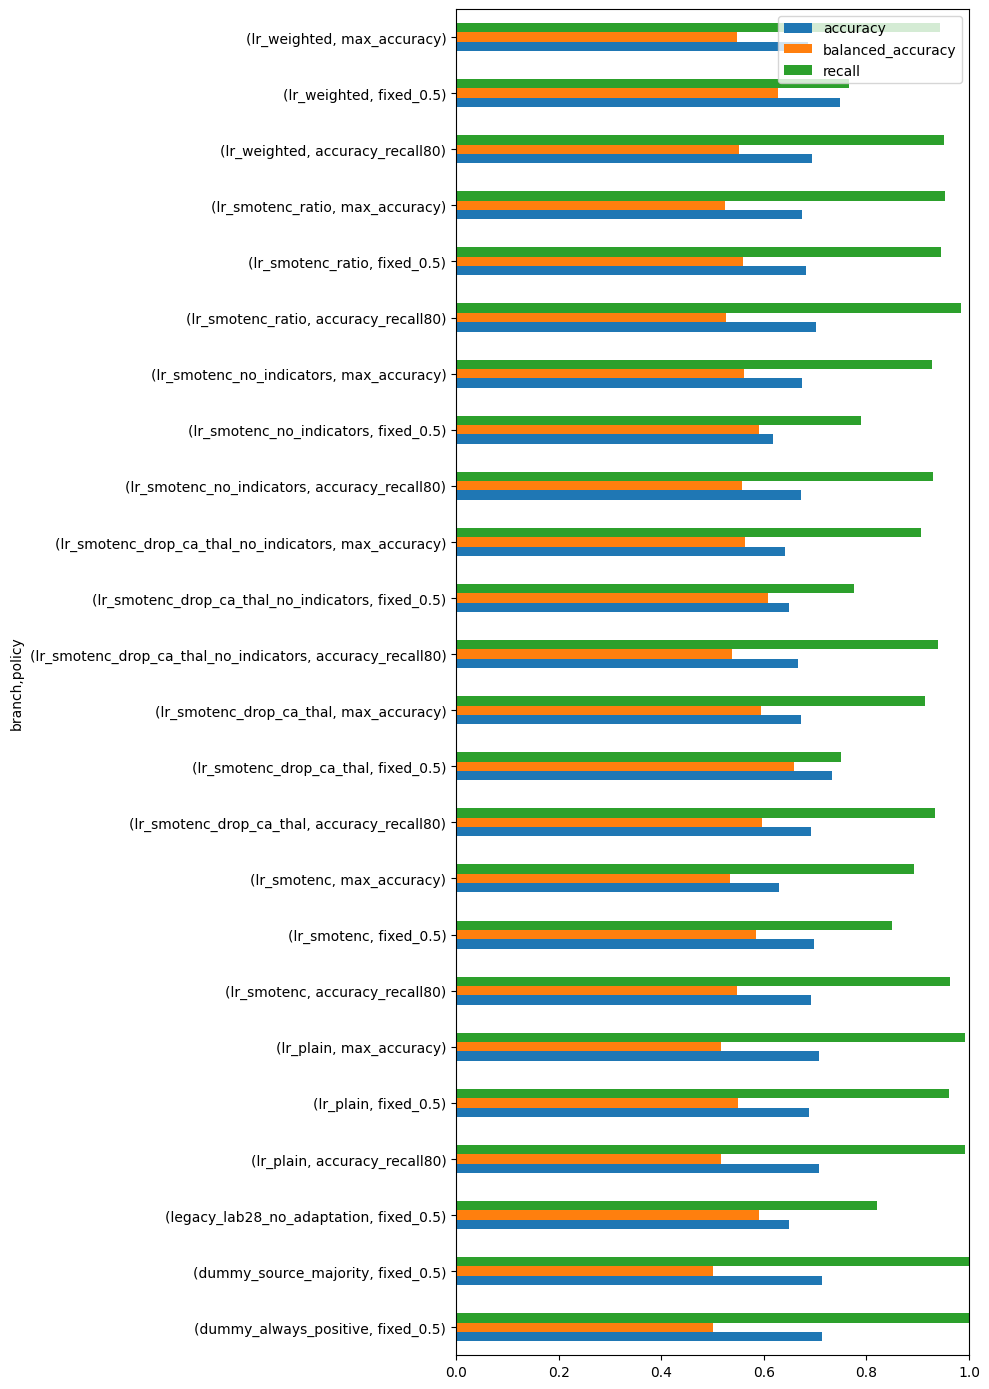

Artifacts: /content/uci_multicenter_lr_accuracy_lab29_results 
ZIP: /content/uci_multicenter_lr_accuracy_lab29_results.zip


In [8]:
METRICS = ['accuracy','balanced_accuracy','recall','specificity','precision','f1',
           'roc_auc','average_precision','brier']
site_results = results.groupby(['branch','policy','site'])[METRICS].mean().reset_index()
summary = site_results.groupby(['branch','policy'])[METRICS].mean()
worst = site_results.groupby(['branch','policy']).agg(
    worst_accuracy=('accuracy','min'), worst_recall=('recall','min'),
    worst_balanced_accuracy=('balanced_accuracy','min'), worst_auc=('roc_auc','min'), worst_brier=('brier','max'))
summary = summary.join(worst).reset_index()
baseline = results[results.branch=='legacy_lab28_no_adaptation'][['site','seed']+METRICS]
paired = results.merge(baseline, on=['site','seed'], suffixes=('', '_legacy'), validate='many_to_one')
for metric in METRICS:
    paired['delta_'+metric] = paired[metric] - paired[metric+'_legacy']
display(summary.sort_values('accuracy', ascending=False).round(4))
display(site_results.round(4))
print('Exploratory comparison; outer ranking is not an unbiased estimate of a selected winner.')
print('Seed variation does not represent uncertainty across independent hospitals.')
for name, frame in dict(raw_results=results, predictions=predictions, site_summary=site_results,
    macro_summary=summary, paired_deltas=paired, tuning=pd.DataFrame(tuning),
    inner_threshold_curves=pd.concat(curves, ignore_index=True)).items():
    frame.to_csv(OUTPUT_DIR / (name+'.csv'), index=False)
config = dict(model_seeds=MODEL_SEEDS, C_grid=C_GRID, ratio_grid=RATIO_GRID,
    thresholds=THRESHOLDS.tolist(), recall_floor=RECALL_FLOOR, branches=BRANCHES,
    legacy_optuna_trials=N_TRIALS, development_sites=DEVELOPMENT_SITES,
    threshold_selection='inner OOF macro accuracy; constrained minimum site recall',
    outer_evaluation='full target hospital, no support removal; Hungarian not loaded',
    versions={p: importlib.metadata.version(p) for p in ['numpy','pandas','scikit-learn','imbalanced-learn','optuna']},
    python=platform.python_version())
(OUTPUT_DIR/'run_config.json').write_text(json.dumps(config, indent=2), encoding='utf-8')
ax = summary.set_index(['branch','policy'])[['accuracy','balanced_accuracy','recall']].plot.barh(figsize=(10,14))
ax.set_xlim(0,1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'development_comparison.png', dpi=160)
plt.show()
zip_path = shutil.make_archive(str(OUTPUT_DIR), 'zip', OUTPUT_DIR)
print('Artifacts:', OUTPUT_DIR, '\nZIP:', zip_path)

## Diễn giải và tài liệu tham khảo
- Accuracy tăng kèm Recall giảm là đánh đổi, không tự động là cải thiện toàn diện.
- Kiểm tra từng site và paired deltas với legacy trên cùng toàn bộ test hospital.
- So sánh các nhánh mới để cô lập sampling/missing indicators/drop ca-thal.
- Chỉ 3 development hospitals: chưa chứng minh tổng quát hóa lâm sàng.
- Không chọn threshold riêng bằng nhãn của outer hospital; không mở Hungarian để thử lại.

1. Steyerberg & Harrell (2016), internal–external validation: https://doi.org/10.1016/j.jclinepi.2015.04.005
2. Varma & Simon (2006), nested CV: https://doi.org/10.1186/1471-2105-7-91
3. Steyerberg et al. (2010), performance metrics: https://doi.org/10.1097/EDE.0b013e3181c30fb2